# 03 — η Contention Sensitivity

Realistic-cost analysis from `05_contention_and_congestion.md`. The framework is:

> α_eff = α · η_α     (η_α ≥ 1, latency inflation)
> BW_eff = BW · η_β   (η_β ∈ (0, 1], bandwidth utilization)

**η profiles are calibrated per fabric+algorithm, not free dials.** Per `05_contention_and_congestion.md` §4.1:

| profile | η_α | η_β | applies to |
|---|---|---|---|
| crossbar | 1.00 | 0.80 | software AR on NVLink + NVSwitch (ring, DBT, Rabenseifner) |
| nvls | 1.00 | 0.52 | NVLink SHARP — only meaningful for INC AR |
| torus | 1.20 | 0.60 | torus dim-decomp with off-prefix concurrent groups |

Applying NVLS η to a software ring AR or torus η to a star+DBT is non-physical — those algorithms don't go through the SHARP / torus paths those η values were measured against. So below we pair each algorithm with its *native* profile, mirroring the §5.1 ladder.

## Setup

In [1]:
%matplotlib inline
import sys, math
from pathlib import Path

REPO = Path.cwd().resolve()
while REPO.name != 'collective_comm' and REPO.parent != REPO:
    REPO = REPO.parent
CODE = REPO / 'code'
if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

import pandas as pd
import matplotlib.pyplot as plt

from core import collective_cost as cc
from core.collective_cost import apply_eta
from util import Anchors, ETA_PROFILES, sweep, to_us

a = Anchors()
M, G, alpha, bw, dims = a.M, a.G, a.alpha, a.bw, a.dims
log_G = math.ceil(math.log2(G))

print(f'Anchor: N={G}, M={M/1e6:.0f} MB, α={alpha*1e6:.2f} μs, BW={bw/1e9:.0f} GB/s')
print(f'Profiles: {list(ETA_PROFILES.keys())}')


Anchor: N=512, M=16 MB, α=0.50 μs, BW=900 GB/s
Profiles: ['ideal', 'crossbar', 'nvls', 'torus']


## Ideal vs realistic AR cost (each pairing on its native profile)

Reproduces the `05_contention_and_congestion.md` §5.1 ladder. Each row is an algorithm running on the fabric it was designed for, with that fabric's calibrated η. DBT uses the dual-touch n_β=2 form per `04_in_network_collectives.md` §3.1.

Note ring AR and Rabenseifner are *also* software on NVSwitch, so they share the crossbar profile with DBT — they're shown for completeness even though no sane tuner ships them at this scale.

In [2]:
# η profiles aren't free dials — each is calibrated to a specific fabric +
# algorithm path:
#   - crossbar (1.00, 0.80) → software AR on NVLink+NVSwitch (no SHARP)
#   - nvls     (1.00, 0.52) → SHARP path; only meaningful for INC AR
#   - torus    (1.20, 0.60) → torus dim-decomp (off-prefix concurrent groups)
# So we pair each algorithm with its native profile (mirroring the
# 05_contention_and_congestion.md §5.1 ladder), not the Cartesian product.

def dbt_dual_touch(M, G, alpha, bw):
    return 2 * log_G * alpha + 2.0 * (M / bw)

# (label, native_profile, callable(alpha, bw))
pairings = [
    ('star + ring AR',          'crossbar', lambda a, b: cc.ring_all_reduce(M, G, a, b)),
    ('star + DBT (dual-touch)', 'crossbar', lambda a, b: dbt_dual_touch(M, G, a, b)),
    ('star + Rabenseifner',     'crossbar', lambda a, b: cc.rabenseifner_all_reduce(M, G, a, b)),
    ('star + INC (NVLS)',       'nvls',     lambda a, b: cc.inc_all_reduce(M, a, b)),
    ('torus 8³ + dim-ring',     'torus',    lambda a, b: cc.torus_all_reduce(M, dims, a, b)),
]

rows = []
for label, profile, fn in pairings:
    eta_a, eta_b = ETA_PROFILES[profile]
    ae, be = apply_eta(alpha, bw, eta_a, eta_b)
    rows.append({
        'pairing':    label,
        'profile':    profile,
        'ideal_us':   to_us(fn(alpha, bw)),
        'realistic_us': to_us(fn(ae, be)),
    })
df_pairs = pd.DataFrame(rows)
df_pairs['inflation_pct'] = (df_pairs['realistic_us'] / df_pairs['ideal_us'] - 1) * 100
df_pairs


,pairing,profile,ideal_us,realistic_us,inflation_pct
0,star + ring AR,crossbar,546.486111,555.357639,1.623377
1,star + DBT (dual-touch),crossbar,44.555556,53.444444,19.950125
2,star + Rabenseifner,crossbar,44.486111,53.357639,19.942242
3,star + INC (NVLS),nvls,18.777778,35.188034,87.391898
4,torus 8³ + dim-ring,torus,56.486111,84.343519,49.317269


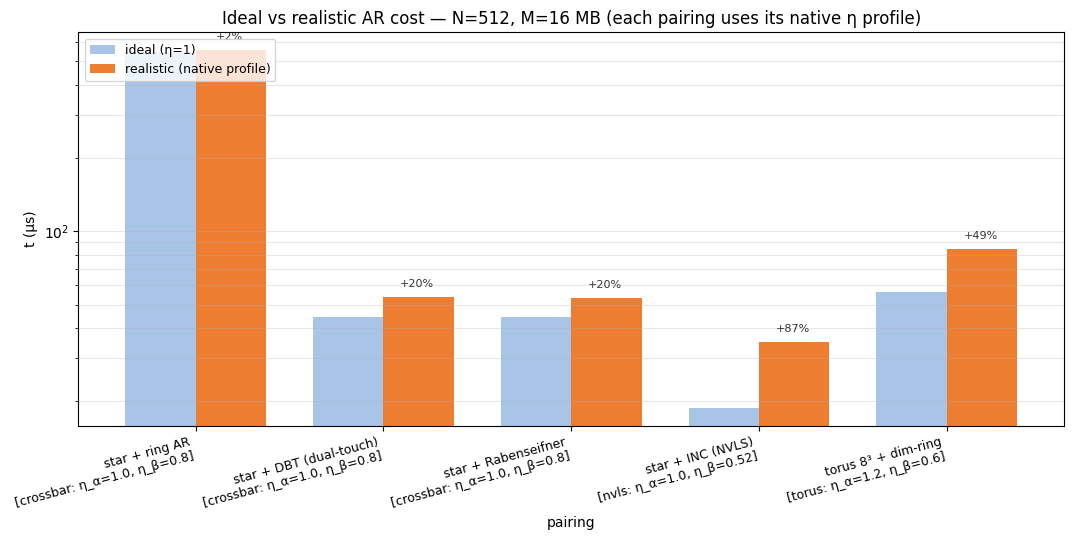

In [3]:
# Build xtick labels that include the native profile so the chart reads
# self-consistently without an external legend.
xtick_labels = []
for _, row in df_pairs.iterrows():
    ea, eb = ETA_PROFILES[row['profile']]
    xtick_labels.append(f'{row["pairing"]}\n[{row["profile"]}: η_α={ea}, η_β={eb}]')

fig, ax = plt.subplots(figsize=(11, 5.5))
piv = df_pairs.set_index('pairing')[['ideal_us', 'realistic_us']]
piv.plot(kind='bar', ax=ax, width=0.75, color=['#a8c5e8', '#ed7d31'])
ax.set_yscale('log')
ax.set_ylabel('t (μs)')
ax.set_title(f'Ideal vs realistic AR cost — N={G}, M={M/1e6:.0f} MB '
             f'(each pairing uses its native η profile)')
ax.legend(['ideal (η=1)', 'realistic (native profile)'], loc='upper left', fontsize=9)
ax.grid(True, axis='y', which='both', alpha=0.3)
ax.set_xticklabels(xtick_labels, rotation=15, ha='right', fontsize=9)

# Inflation % annotation above each realistic bar
for i, (_, row) in enumerate(df_pairs.iterrows()):
    ax.text(i + 0.18, row['realistic_us'] * 1.10,
            f'+{row["inflation_pct"]:.0f}%', ha='center', fontsize=8, alpha=0.8)
plt.tight_layout(); plt.show()


## Sensitivity to η_β

Each algorithm's curve = its cost as a function of *its own* η_β degrading from 1.0 down to 0.4. Slope = `n_β · M / BW` — INC has `n_β=1`, the others have `n_β=2`, so the software algorithms degrade ~2× faster on the BW side. The hollow markers are each algorithm's native operating point per the §4.1 calibration table.

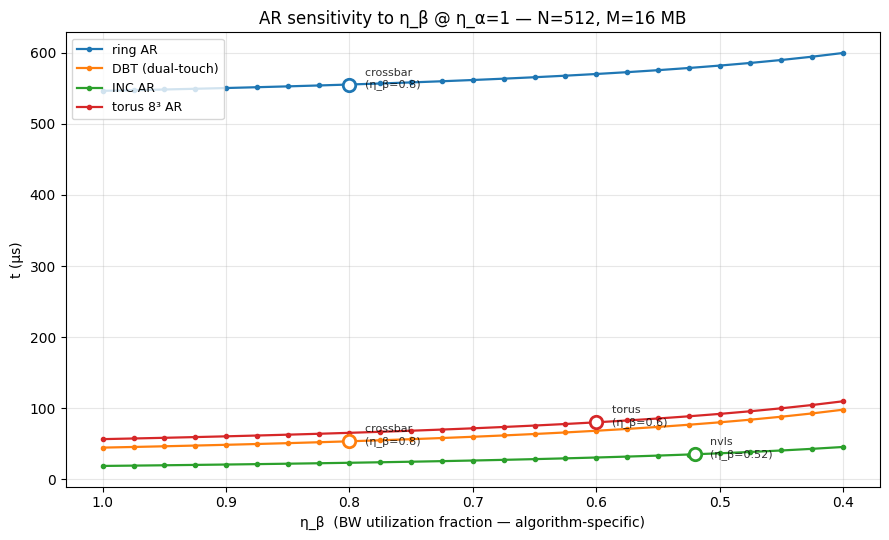

In [4]:
# How sensitive is each algorithm's cost to its OWN η_β degrading?
# Slope = n_β · M / BW. INC has n_β=1, ring/DBT/torus have n_β=2 → ring/DBT/torus
# degrade ~2× faster on the BW side as utilization drops.
def linspace(a, b, n):
    return [a + (b - a) * i / (n - 1) for i in range(n)]

eta_betas = linspace(0.4, 1.0, 25)

# For each algorithm, also note its native operating-point η_β so we can
# scatter-mark where each one lives in the real world.
algo_specs = [
    ('ring AR',          'crossbar',
     lambda eb: cc.ring_all_reduce(M, G, *apply_eta(alpha, bw, 1.0, eb))),
    ('DBT (dual-touch)', 'crossbar',
     lambda eb: dbt_dual_touch(M, G, *apply_eta(alpha, bw, 1.0, eb))),
    ('INC AR',           'nvls',
     lambda eb: cc.inc_all_reduce(M, *apply_eta(alpha, bw, 1.0, eb))),
    ('torus 8³ AR',      'torus',
     lambda eb: cc.torus_all_reduce(M, dims, *apply_eta(alpha, bw, 1.0, eb))),
]

curves_eb = {label: fn for label, _, fn in algo_specs}
df_eb = sweep(curves_eb, eta_betas, x_name='eta_beta')

fig, ax = plt.subplots(figsize=(9, 5.5))
for label, sub in df_eb.groupby('label', sort=False):
    line, = ax.plot(sub['eta_beta'], sub['t_us'], marker='.', linewidth=1.6, label=label)
    # Scatter-mark this algorithm's native operating point.
    profile = next(p for l, p, _ in algo_specs if l == label)
    eta_b_native = ETA_PROFILES[profile][1]
    fn = next(f for l, _, f in algo_specs if l == label)
    t_native = fn(eta_b_native) * 1e6
    ax.scatter([eta_b_native], [t_native], s=80, zorder=5,
               edgecolor=line.get_color(), facecolor='white', linewidth=2)
    ax.annotate(f'  {profile}\n  (η_β={eta_b_native})',
                xy=(eta_b_native, t_native), fontsize=8, alpha=0.8,
                xytext=(6, -2), textcoords='offset points')
ax.set_xlabel('η_β  (BW utilization fraction — algorithm-specific)')
ax.set_ylabel('t (μs)')
ax.set_title(f'AR sensitivity to η_β @ η_α=1 — N={G}, M={M/1e6:.0f} MB')
ax.invert_xaxis()
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## Fat-tree oversubscription

Per `05_contention_and_congestion.md` §4.1, scale-out fabric η_β is bounded by `min(η_β_hw, 1/s)` where `s` is the oversubscription ratio. As `s` grows the BW ceiling crashes — at s=4 a fabric with η_β_hw=0.80 effectively delivers only η_β=0.25.

Different algorithms have different baseline η_β_hw because INC vs software use different switch hardware paths.

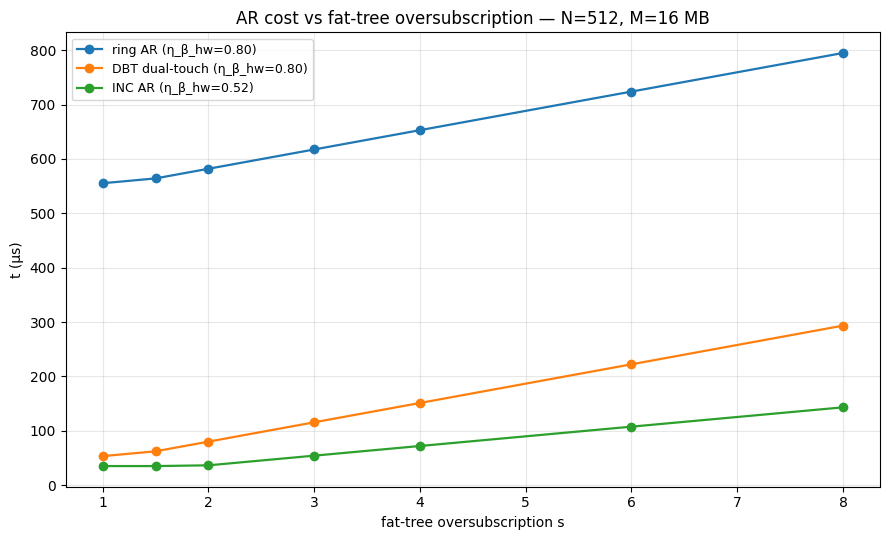

label,DBT dual-touch (η_β_hw=0.80),INC AR (η_β_hw=0.52),ring AR (η_β_hw=0.80)
s,,,
1.0,53.444444,35.188034,555.357639
1.5,62.333333,35.188034,564.229167
2.0,80.111111,36.555556,581.972222
3.0,115.666667,54.333333,617.458333
4.0,151.222222,72.111111,652.944444
6.0,222.333333,107.666667,723.916667
8.0,293.444444,143.222222,794.888889


In [5]:
# Fat-tree oversubscription s ∈ [1, 8]: outer-tier η_β = min(η_β_hw, 1/s).
# Hold the inner tier ideal; sweep what happens to scale-out AR options.
# Per 05_contention_and_congestion.md §4.1.

s_values = [1, 1.5, 2, 3, 4, 6, 8]

def cost_under_s(algo_fn, hw_eta_beta, s):
    eta_b = min(hw_eta_beta, 1.0 / s)
    ae, be = apply_eta(alpha, bw, 1.0, eta_b)
    return algo_fn(ae, be)

curves_s = {
    'ring AR (η_β_hw=0.80)':         lambda s: cost_under_s(
        lambda a, b: cc.ring_all_reduce(M, G, a, b), 0.80, s),
    'DBT dual-touch (η_β_hw=0.80)':  lambda s: cost_under_s(
        lambda a, b: dbt_dual_touch(M, G, a, b), 0.80, s),
    'INC AR (η_β_hw=0.52)':          lambda s: cost_under_s(
        lambda a, b: cc.inc_all_reduce(M, a, b), 0.52, s),
}
df_s = sweep(curves_s, s_values, x_name='s')

fig, ax = plt.subplots(figsize=(9, 5.5))
for label, sub in df_s.groupby('label', sort=False):
    ax.plot(sub['s'], sub['t_us'], marker='o', linewidth=1.6, label=label)
ax.set_xlabel('fat-tree oversubscription s')
ax.set_ylabel('t (μs)')
ax.set_title(f'AR cost vs fat-tree oversubscription — N={G}, M={M/1e6:.0f} MB')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()
df_s.pivot(index='s', columns='label', values='t_us')


## Key takeaways

1. **INC AR retains its lead under realistic η** even though its η_β=0.52 looks worst on paper. Reason: η_β is measured against raw BW with no n_β slack, so INC's `n_β=1` framing makes its η_β look pessimistic; realized goodput `0.52·BW` still beats DBT's `0.80·BW / 2 = 0.40·BW` by ~1.3× (`05_contention_and_congestion.md` §4.1).
2. **η profiles are not interchangeable.** NVLS η only describes the SHARP path; applying it to a software ring AR is non-physical. The §5.1 ladder pairs each algorithm with its native fabric.
3. **Torus has compounding penalties** (η_α=1.2 inflates the hop count *and* η_β=0.6 deflates BW), but cube-root α scaling keeps it under DBT at N=512.
4. **Fat-tree oversubscription is brutal.** s=4 turns INC AR's 35 μs lead into a ~70 μs penalty. Topology choice should anticipate the deployed `s`.